# Module-4: Data Processing for Timeseries Forecasting	


# A- Overview of the Section




# 1-Dataset Significance


2. Famous platforms for authenticated datasets

    1. <a href="https://www.kaggle.com/datasets">Kaggle</a>
    
    2. <a href="https://github.com/A-I-Studio/Datasets">Github</a>
    
    3. <a href="https://huggingface.co/datasets">Hugging Face</a>
    
    4. <a href="https://www.worlddata.info/">Data World</a>
    

So now lets start working on our dataset

# 2-Overview of the Dataset

**1. Import Libraries**


In [1]:
import pandas as pd
import numpy as np
air_pollution = pd.read_csv('air_pollution.csv', parse_dates=['date'])

air_pollution.set_index('date', inplace=True)

air_pollution

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain
date,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0
...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0


In [2]:
air_pollution.asfreq('h')

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain
date,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0
...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0


In [3]:
air_pollution.index

DatetimeIndex(['2010-01-02 00:00:00', '2010-01-02 01:00:00',
               '2010-01-02 02:00:00', '2010-01-02 03:00:00',
               '2010-01-02 04:00:00', '2010-01-02 05:00:00',
               '2010-01-02 06:00:00', '2010-01-02 07:00:00',
               '2010-01-02 08:00:00', '2010-01-02 09:00:00',
               ...
               '2014-12-31 14:00:00', '2014-12-31 15:00:00',
               '2014-12-31 16:00:00', '2014-12-31 17:00:00',
               '2014-12-31 18:00:00', '2014-12-31 19:00:00',
               '2014-12-31 20:00:00', '2014-12-31 21:00:00',
               '2014-12-31 22:00:00', '2014-12-31 23:00:00'],
              dtype='datetime64[ns]', name='date', length=43800, freq=None)

In [4]:
air_pollution.index = pd.date_range(start="2010-01-02 00:00:00", periods=len(air_pollution), freq="h")

In [5]:
air_pollution.index

DatetimeIndex(['2010-01-02 00:00:00', '2010-01-02 01:00:00',
               '2010-01-02 02:00:00', '2010-01-02 03:00:00',
               '2010-01-02 04:00:00', '2010-01-02 05:00:00',
               '2010-01-02 06:00:00', '2010-01-02 07:00:00',
               '2010-01-02 08:00:00', '2010-01-02 09:00:00',
               ...
               '2014-12-31 14:00:00', '2014-12-31 15:00:00',
               '2014-12-31 16:00:00', '2014-12-31 17:00:00',
               '2014-12-31 18:00:00', '2014-12-31 19:00:00',
               '2014-12-31 20:00:00', '2014-12-31 21:00:00',
               '2014-12-31 22:00:00', '2014-12-31 23:00:00'],
              dtype='datetime64[ns]', length=43800, freq='h')

In [6]:
# Convert to datetime and change format
#df["date"] = pd.to_datetime(df["timestamp"]).dt.strftime("%Y-%m-%d")
#air_pollution.index = pd.to_datetime(air_pollution.index).strftime("%Y-%m-%d")


In [7]:
air_pollution.head(3)

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0


In [8]:
air_pollution.tail(3)

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0
2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0
2014-12-31 23:00:00,12.0,-21,-3.0,1034.0,NW,249.85,0,0


# 3- Manipulation in the Dataset

**1. Lets have the overview of our dataset here**

In [9]:
air_pollution.columns

Index(['pollution_today', 'dew', 'temp', 'press', 'wnd_dir', 'wnd_spd', 'snow',
       'rain'],
      dtype='object')

**Lets Checkout the details about the dataset**

In [10]:
air_pollution.describe()

,pollution_today,dew,temp,press,wnd_spd,snow,rain
count,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,94.013516,1.828516,12.459041,1016.447306,23.894307,0.052763,0.195023
std,92.252276,14.429326,12.193384,10.271411,50.022729,0.760582,1.416247
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,24.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,68.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,132.250000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


**Cover it into a data frame**

In [11]:
air_pollution=pd.DataFrame(air_pollution)
air_pollution

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0
...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0
2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0


# 4- Data Preprocessing

Lets check each feature values


In [12]:
from matplotlib import pyplot as plt

In [13]:
values = air_pollution.values

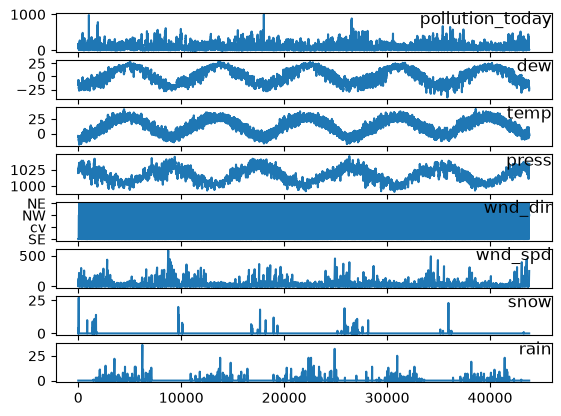

In [14]:
groups = [0,1,2,3,4,5,6,7]
i=1

for group in groups:
    #plt.figure(num=None,figsize=(6,5),dpi=80, facecolor='w', edgecolor='k')
    plt.subplot(len(groups),1,i)
    
    plt.plot(values[:,group])
    plt.title(air_pollution.columns[group], y=0.5, loc="right")
    i +=1

plt.show()

In [15]:
air_pollution.index

DatetimeIndex(['2010-01-02 00:00:00', '2010-01-02 01:00:00',
               '2010-01-02 02:00:00', '2010-01-02 03:00:00',
               '2010-01-02 04:00:00', '2010-01-02 05:00:00',
               '2010-01-02 06:00:00', '2010-01-02 07:00:00',
               '2010-01-02 08:00:00', '2010-01-02 09:00:00',
               ...
               '2014-12-31 14:00:00', '2014-12-31 15:00:00',
               '2014-12-31 16:00:00', '2014-12-31 17:00:00',
               '2014-12-31 18:00:00', '2014-12-31 19:00:00',
               '2014-12-31 20:00:00', '2014-12-31 21:00:00',
               '2014-12-31 22:00:00', '2014-12-31 23:00:00'],
              dtype='datetime64[ns]', length=43800, freq='h')

In [16]:
#pd.date_range(start="2026-01-01", periods=len(air_pollution), freq="H")

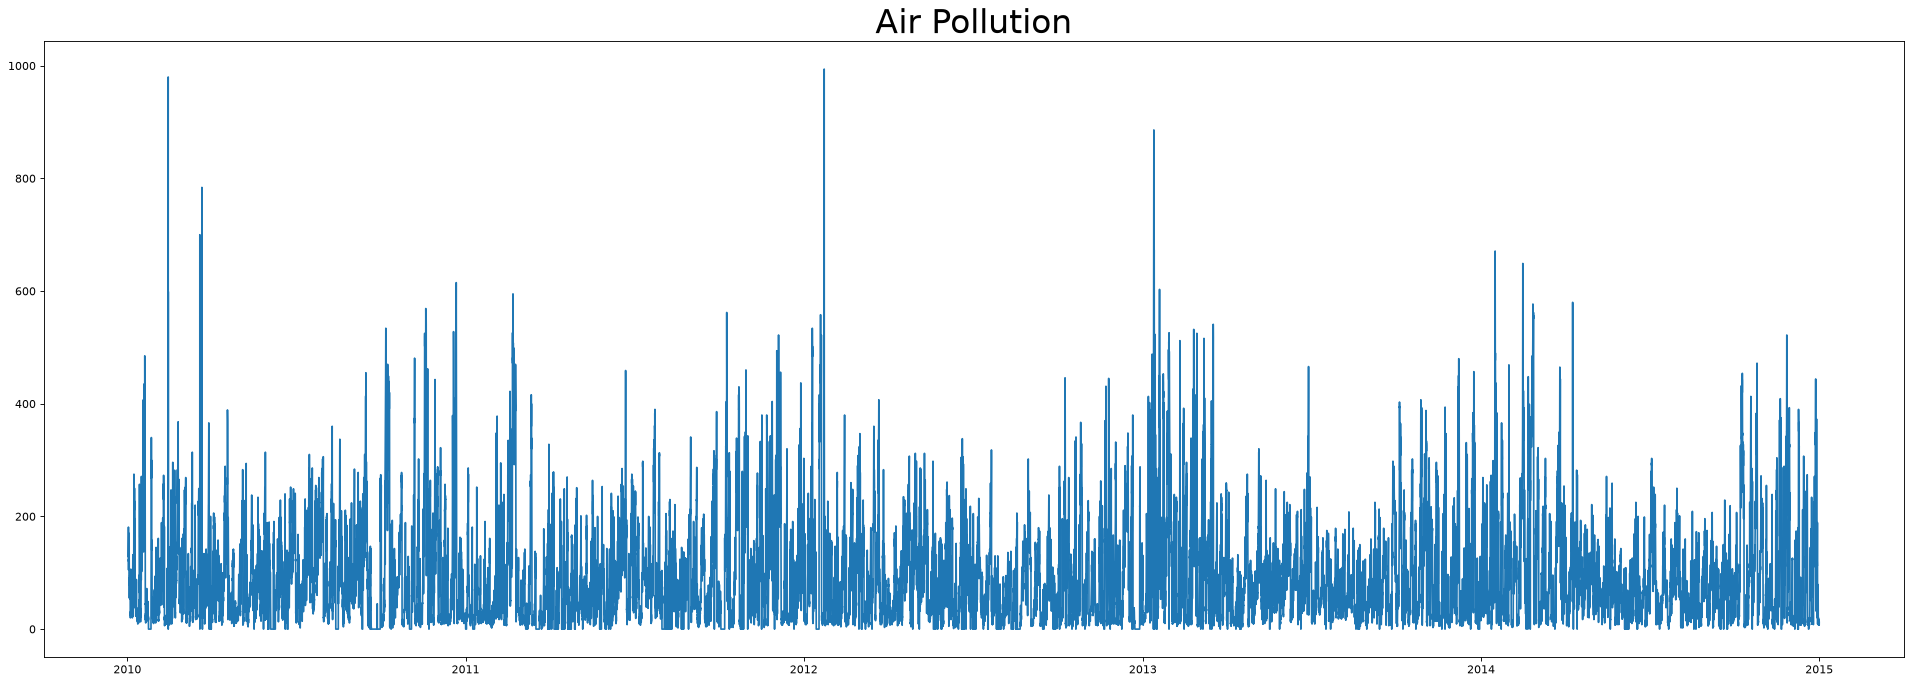

In [17]:
plt.figure(num=None, figsize=(30,10), dpi=80, facecolor='w', edgecolor='k')
plt.title('Air Pollution', fontsize=30)
plt.plot(air_pollution.pollution_today)
#plt.xticks(ticks=range(2010,2015), labels=list(map(str,range(2010,2015))))
plt.show()

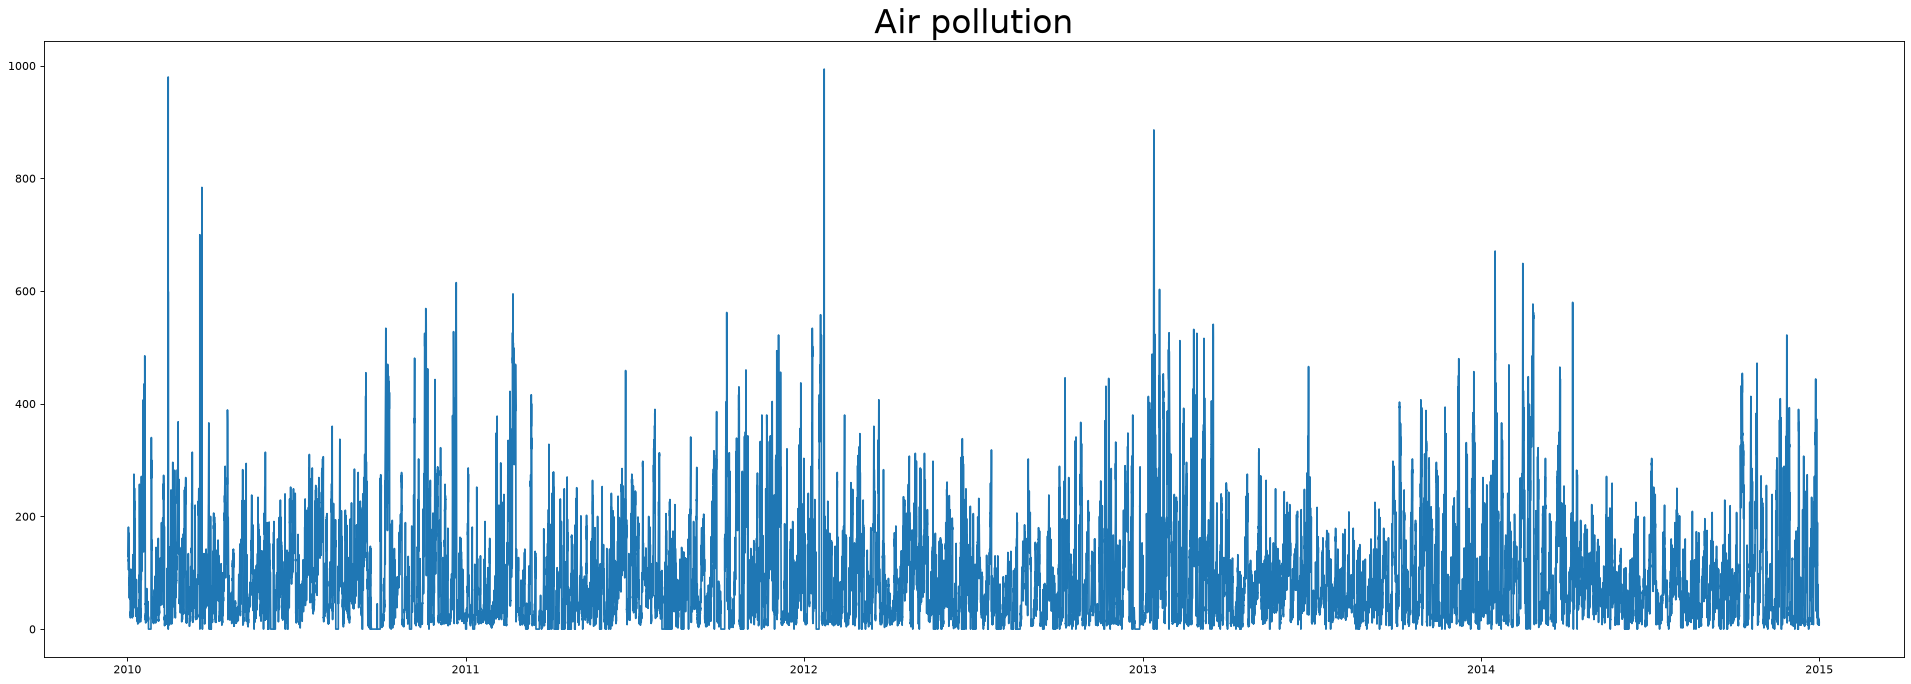

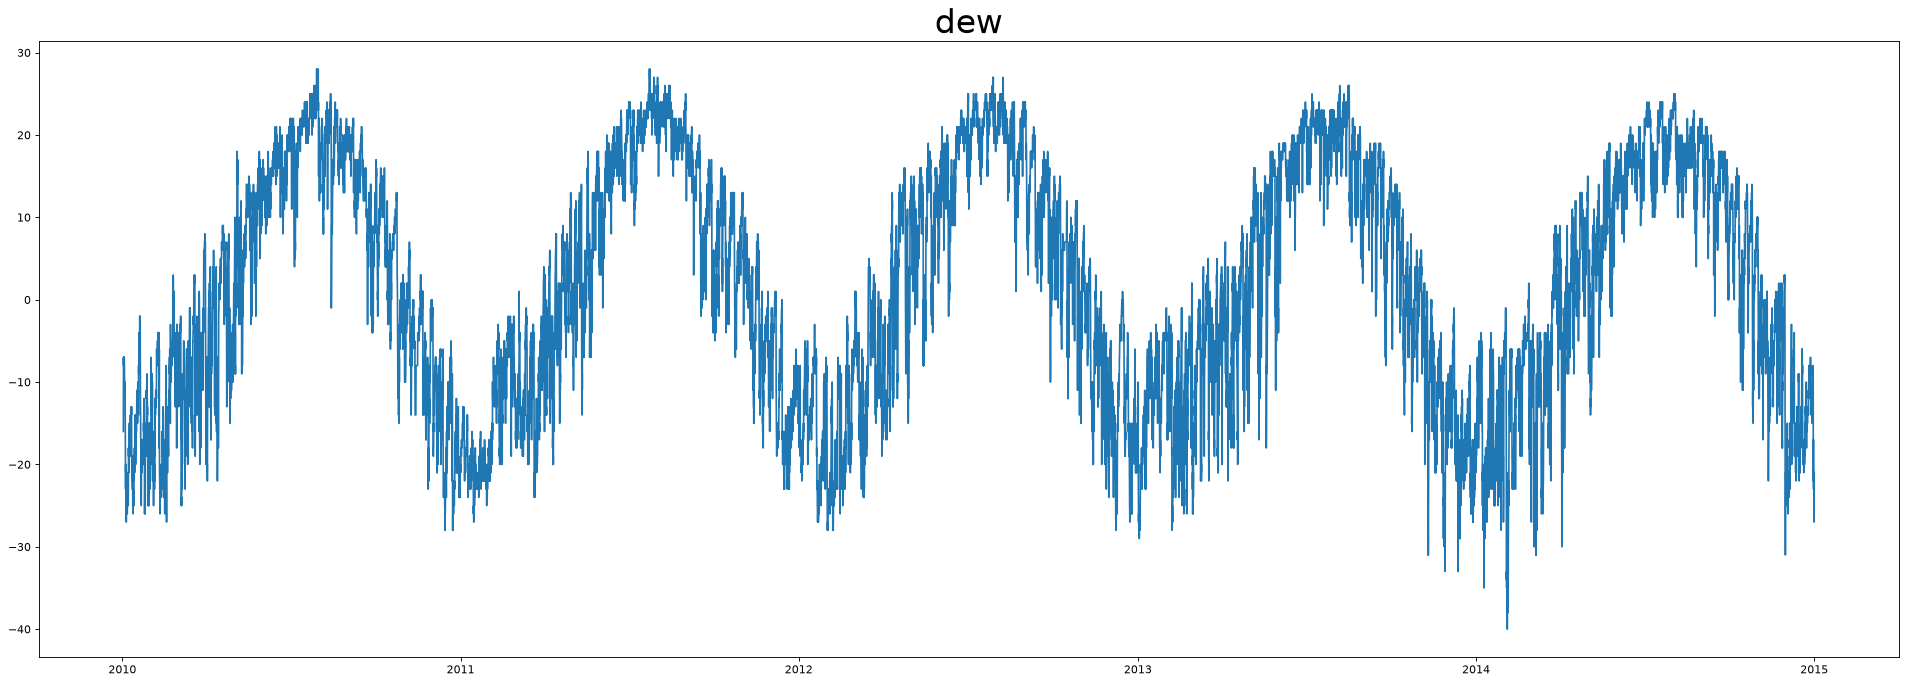

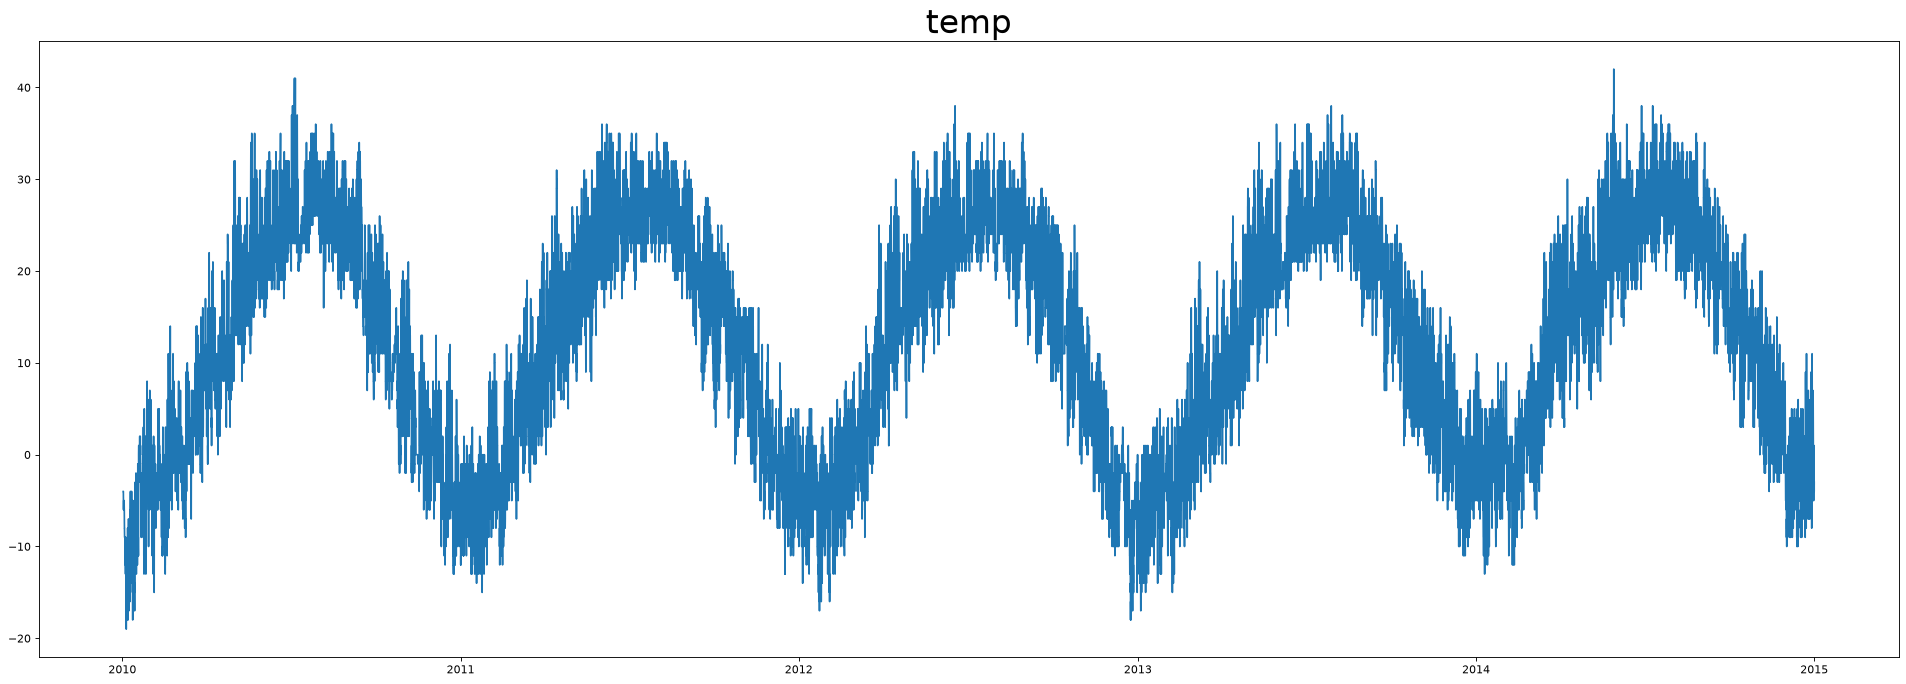

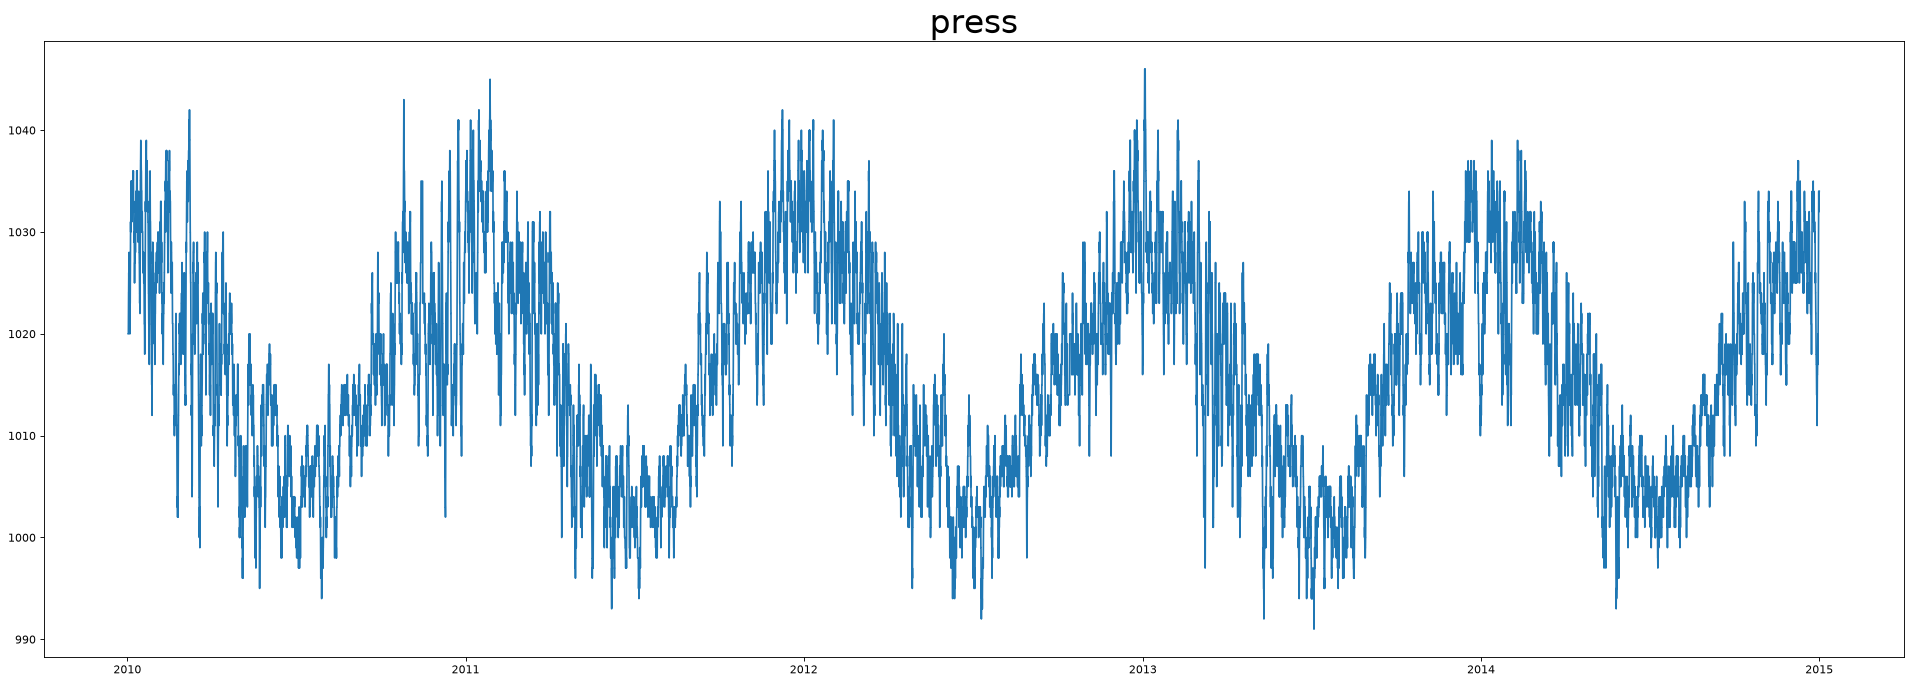

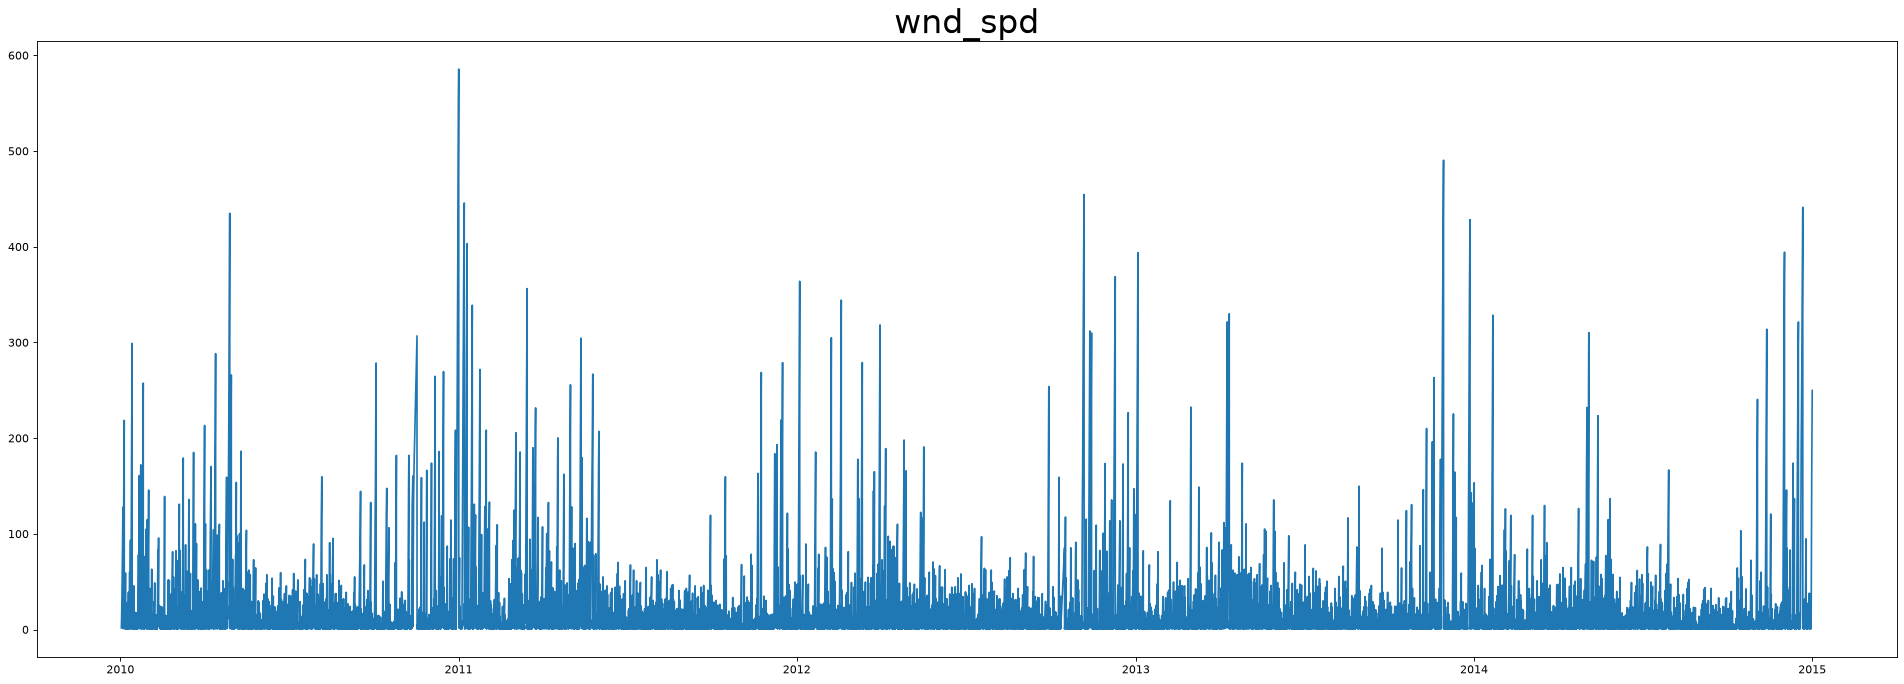

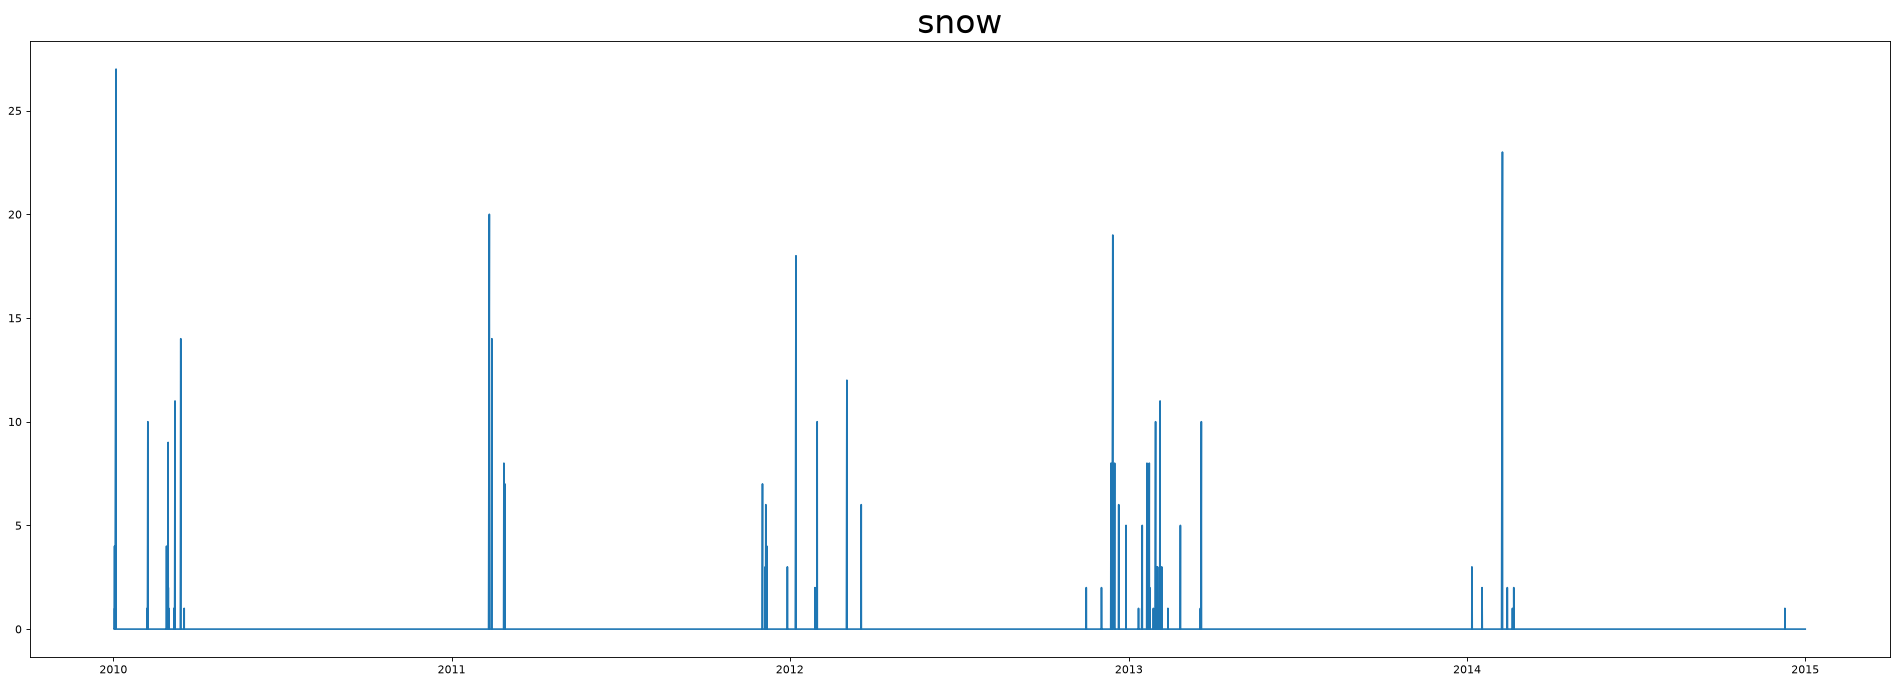

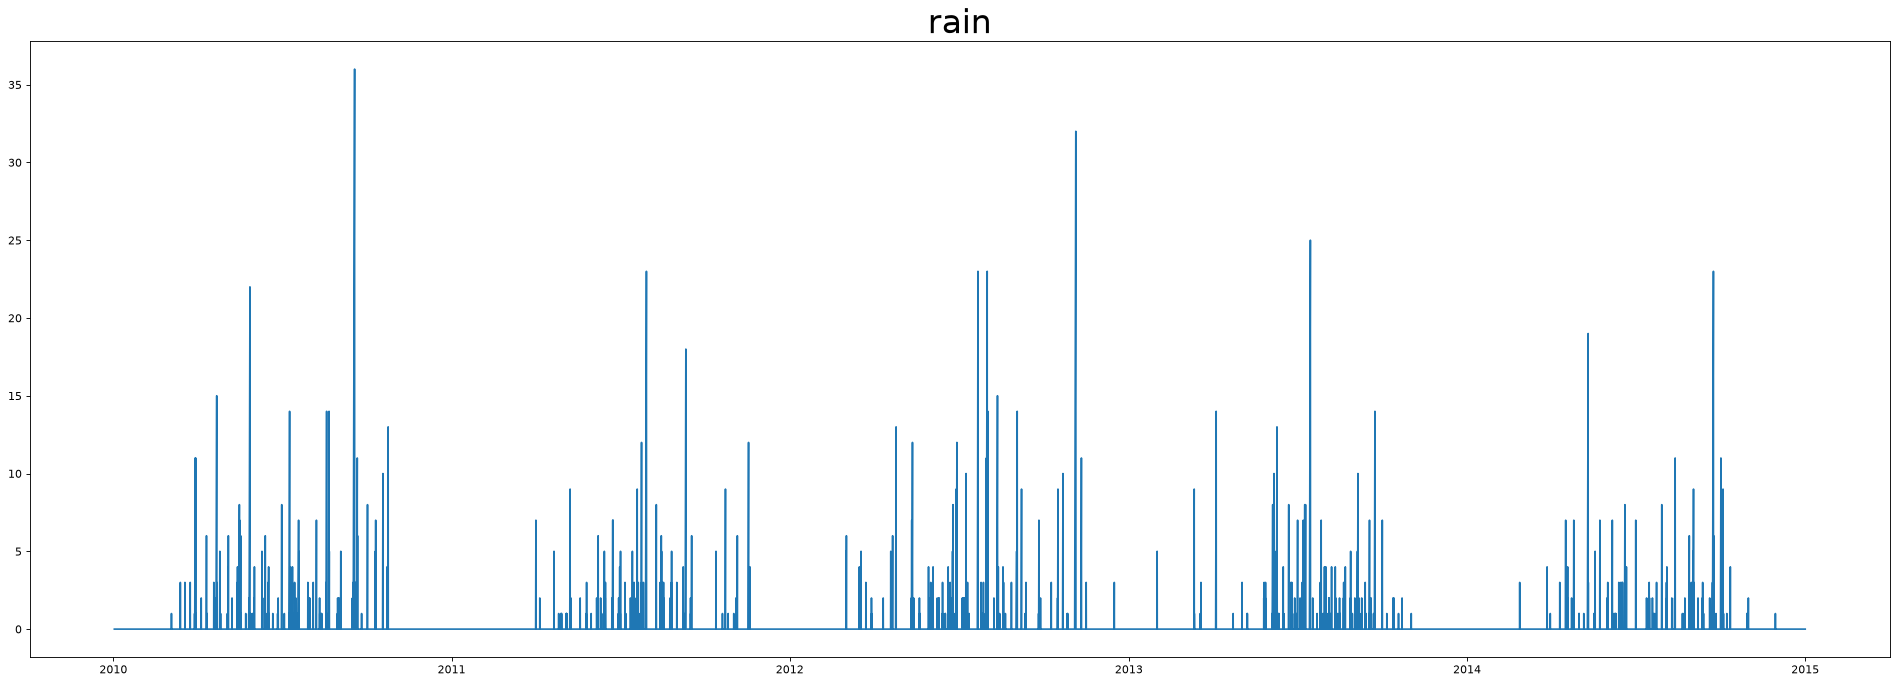

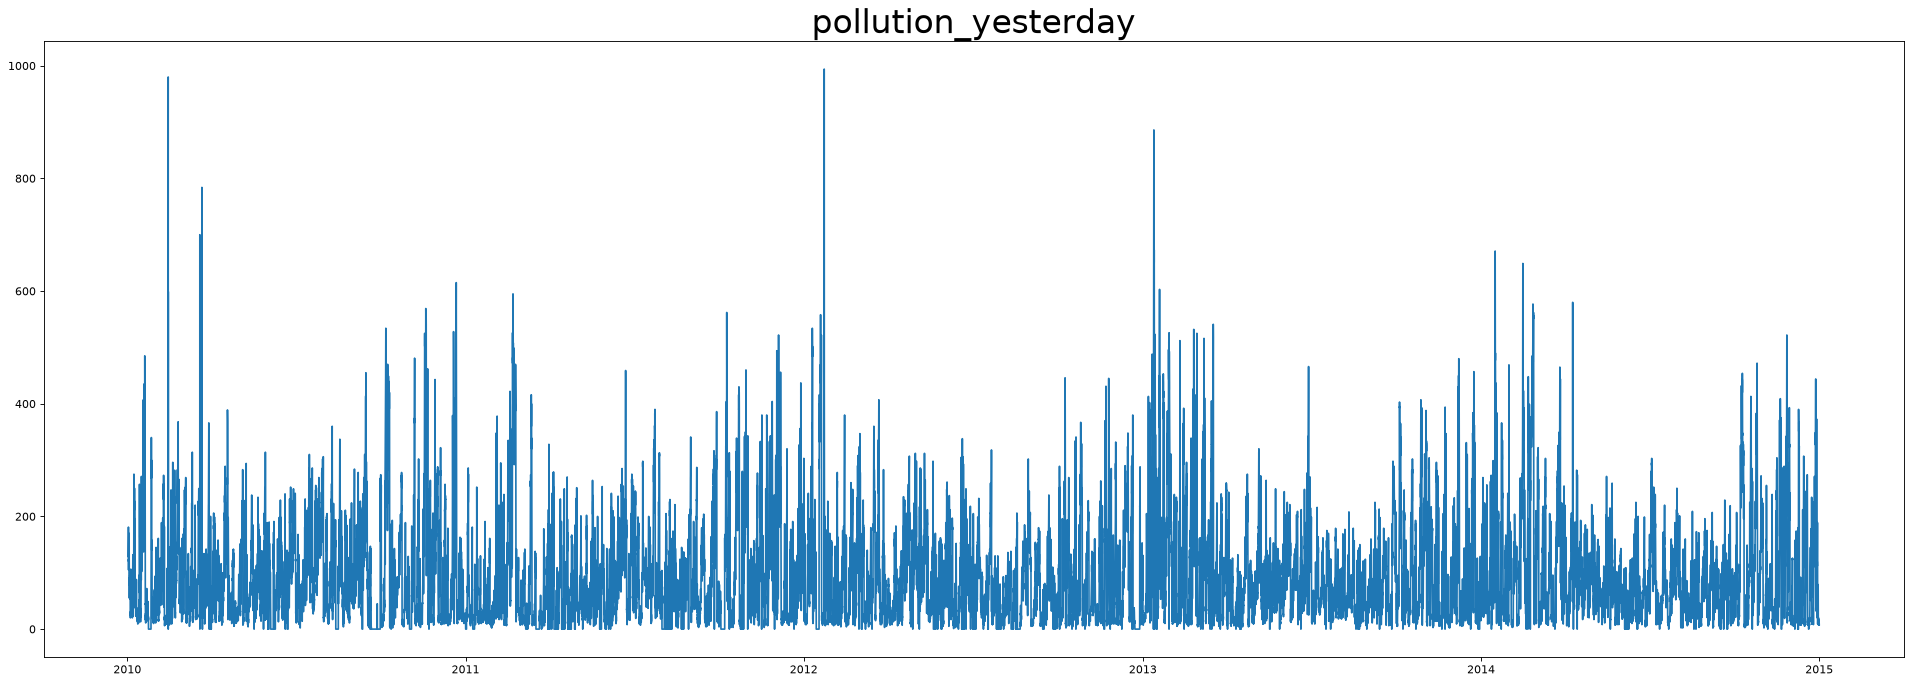

In [18]:
plt.figure(num=None, figsize=(30, 10), dpi=80, facecolor='w', edgecolor='k')
#fontsize is set to 30 for better visualization
plt.title('Air pollution', fontsize=30)
#air_pollution.pollution_today will pick the valus of the colomn pollution_today from air_pollution disctionary / dataset
plt.plot(air_pollution.pollution_today)
plt.show()
#Dewpoint visualization, and The dew point is the temperature the air needs to be cooled.
plt.figure(num=None, figsize=(30, 10), dpi=80, facecolor='w', edgecolor='k')
plt.title('dew', fontsize=30)
plt.plot(air_pollution.dew)
plt.show()
#Temperature Visualization
plt.figure(num=None, figsize=(30, 10), dpi=80, facecolor='w', edgecolor='k')
plt.title('temp', fontsize=30)
plt.plot(air_pollution.temp)
plt.show()
#air pressure visualization
plt.figure(num=None, figsize=(30, 10), dpi=80, facecolor='w', edgecolor='k')
plt.title('press', fontsize=30)
plt.plot(air_pollution.press)
plt.show()
#wind speed visualization of the span of 4 year
plt.figure(num=None, figsize=(30, 10), dpi=80, facecolor='w', edgecolor='k')
plt.title('wnd_spd', fontsize=30)
plt.plot(air_pollution.wnd_spd)
plt.show()
#Snow Visualization
plt.figure(num=None, figsize=(30, 10), dpi=80, facecolor='w', edgecolor='k')
plt.title('snow', fontsize=30)
plt.plot(air_pollution.snow)
plt.show()
#Rain Visualization
plt.figure(num=None, figsize=(30, 10), dpi=80, facecolor='w', edgecolor='k')
plt.title('rain', fontsize=30)
plt.plot(air_pollution.rain)
plt.show()
#Yesterday's air pollution
air_pollution['pollution_yesterday']=air_pollution['pollution_today'].shift(1)
plt.figure(num=None, figsize=(30, 10), dpi=80, facecolor='w', edgecolor='k')
plt.title('pollution_yesterday', fontsize=30)
plt.plot(air_pollution.pollution_yesterday)
plt.show()

# 7. RVT Models in Time Series in Python
The Concept of Resampling, Visualize and Transform

# Automatic time series decomposition

**Lets Define few libraries which we will be using in Automatic Time Series Decomposition

In [19]:
import tensorflow as tf
import statsmodels as sm
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)


plt.style.use('bmh')

from pylab import rcParams
import matplotlib as mpl

mpl.rcParams['axes.labelsize']=14
mpl.rcParams['xtick.labelsize']=12
mpl.rcParams['ytick.labelsize']=12
mpl.rcParams['text.color']='k'

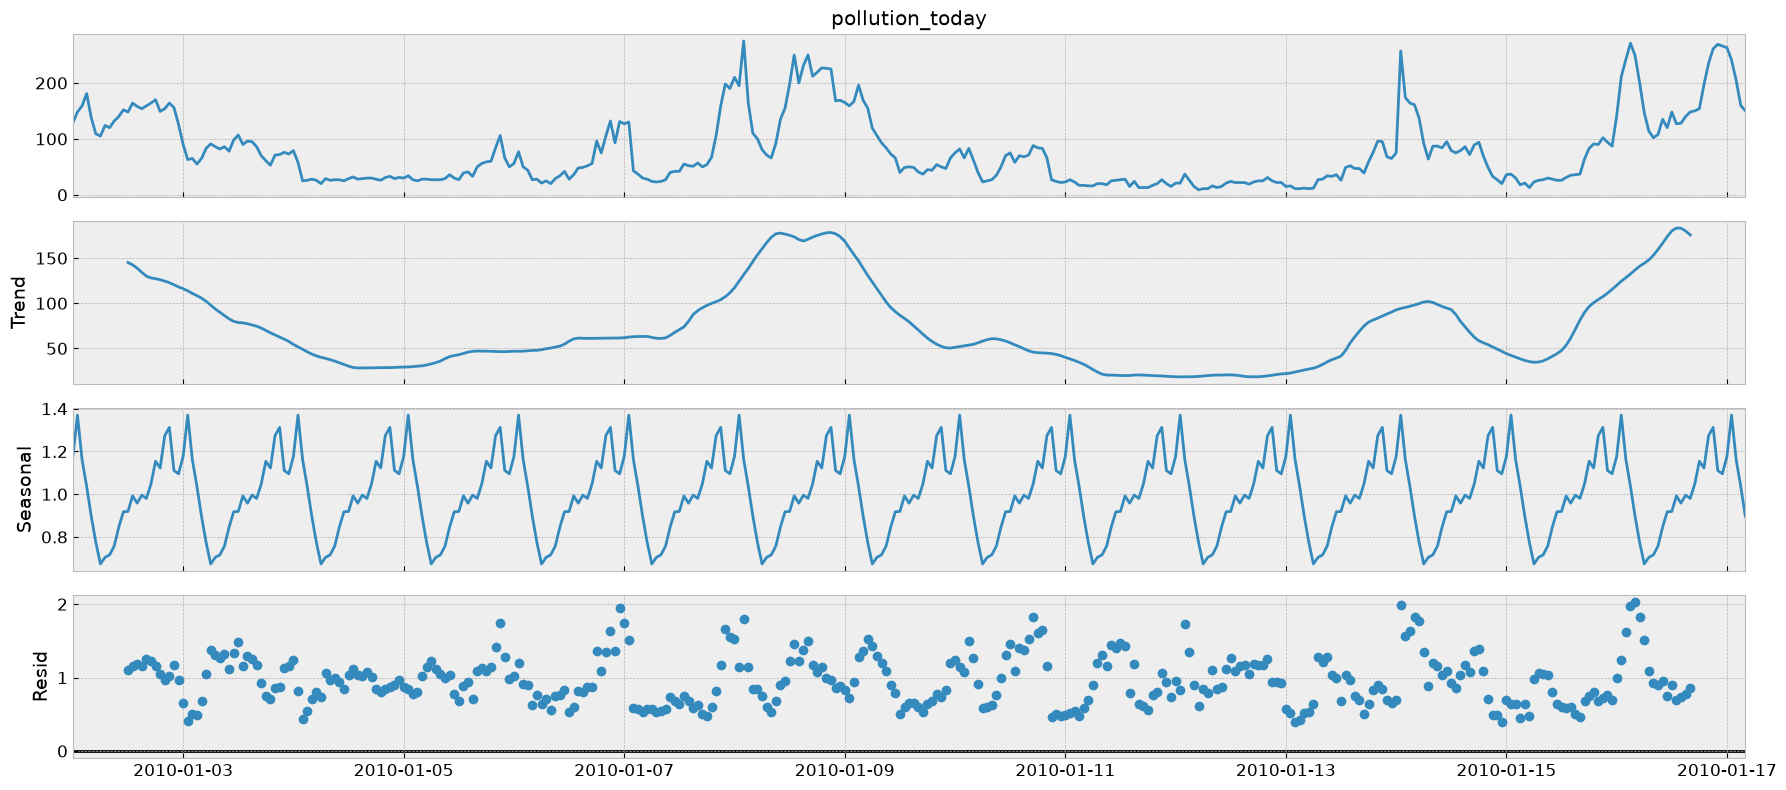

<Figure size 4000x1600 with 0 Axes>

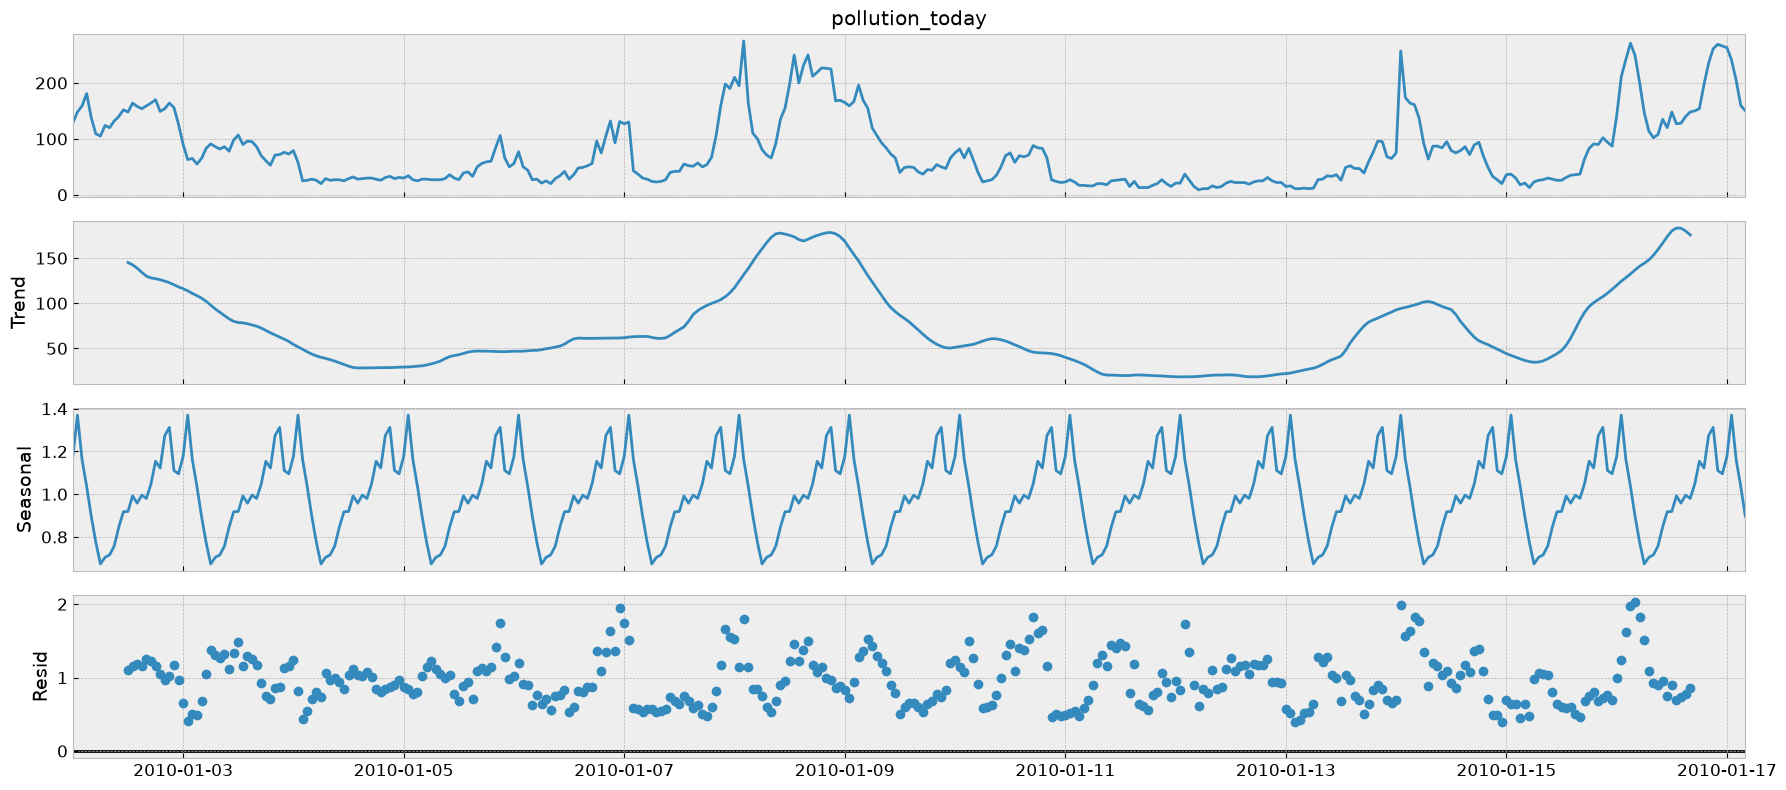

In [20]:
rcParams['figure.figsize']=18, 8
plt.figure(num=None, figsize=(50,20), dpi=80, facecolor='w',edgecolor='k')
series = air_pollution.pollution_today[:365] #primeras 365 horas

result= seasonal_decompose(series, model='multiplicative')
result.plot()

# Trend  in Automatic Time Series Decomposition using Moving Average Filter 

In [21]:
import sklearn
from sklearn import linear_model
from sklearn.linear_model import LinearRegression

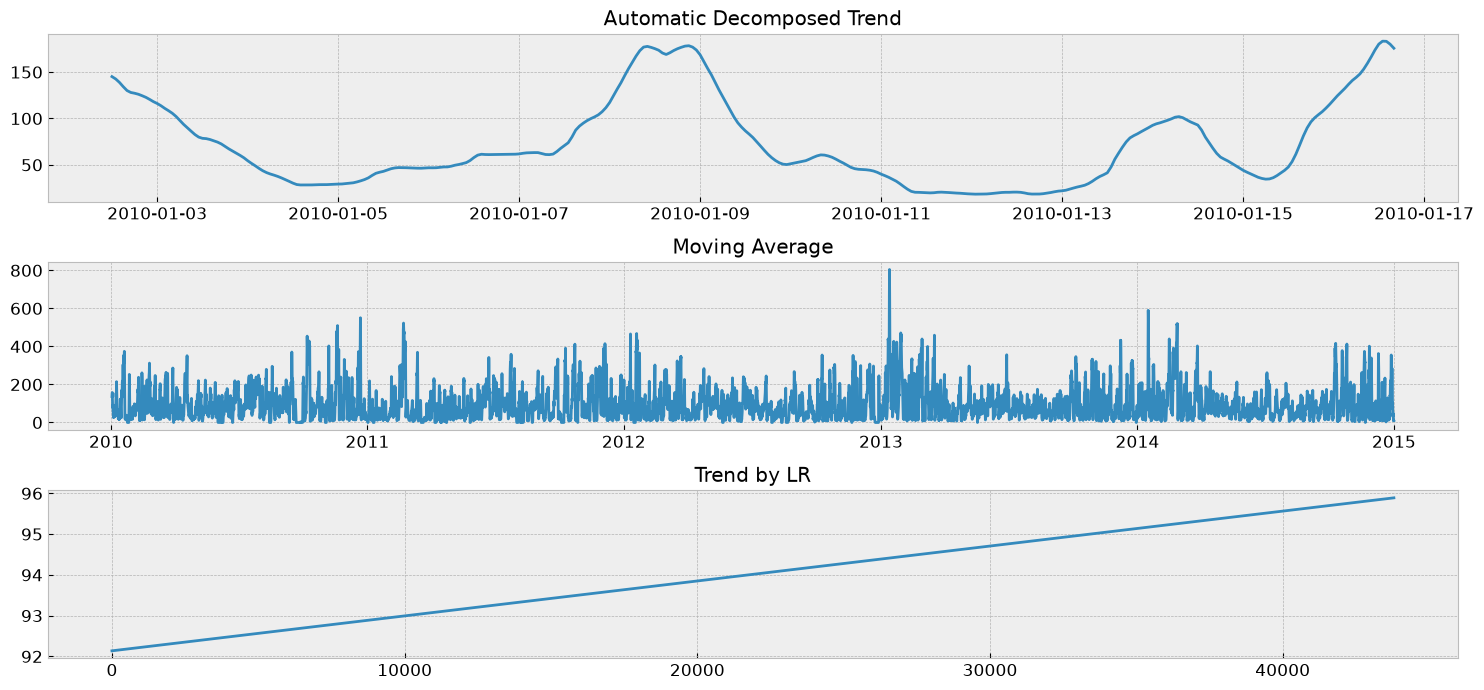

In [22]:
fig = plt.figure(figsize=(15,7))
layout=(3,1)
pm_ax = plt.subplot2grid(layout,(0,0), colspan=2)
mv_ax = plt.subplot2grid(layout,(1,0), colspan=2)
fit_ax = plt.subplot2grid(layout,(2,0), colspan=2)

pm_ax.plot(result.trend)
pm_ax.set_title("Automatic Decomposed Trend")

mm = air_pollution.pollution_today.rolling(12).mean()
mv_ax.plot(mm)
mv_ax.set_title("Moving Average")

X = [i for i in range(0, len(air_pollution.pollution_today))]
X = np.reshape(X, (len(X), 1)) 
y = air_pollution.pollution_today.values 

model = LinearRegression()
model.fit(X, y)

trend = model.predict(X)

fit_ax.plot(trend)
fit_ax.set_title("Trend by LR")

plt.tight_layout()
plt.show()

# Seasonality in Automatic Time Series Decomposition 

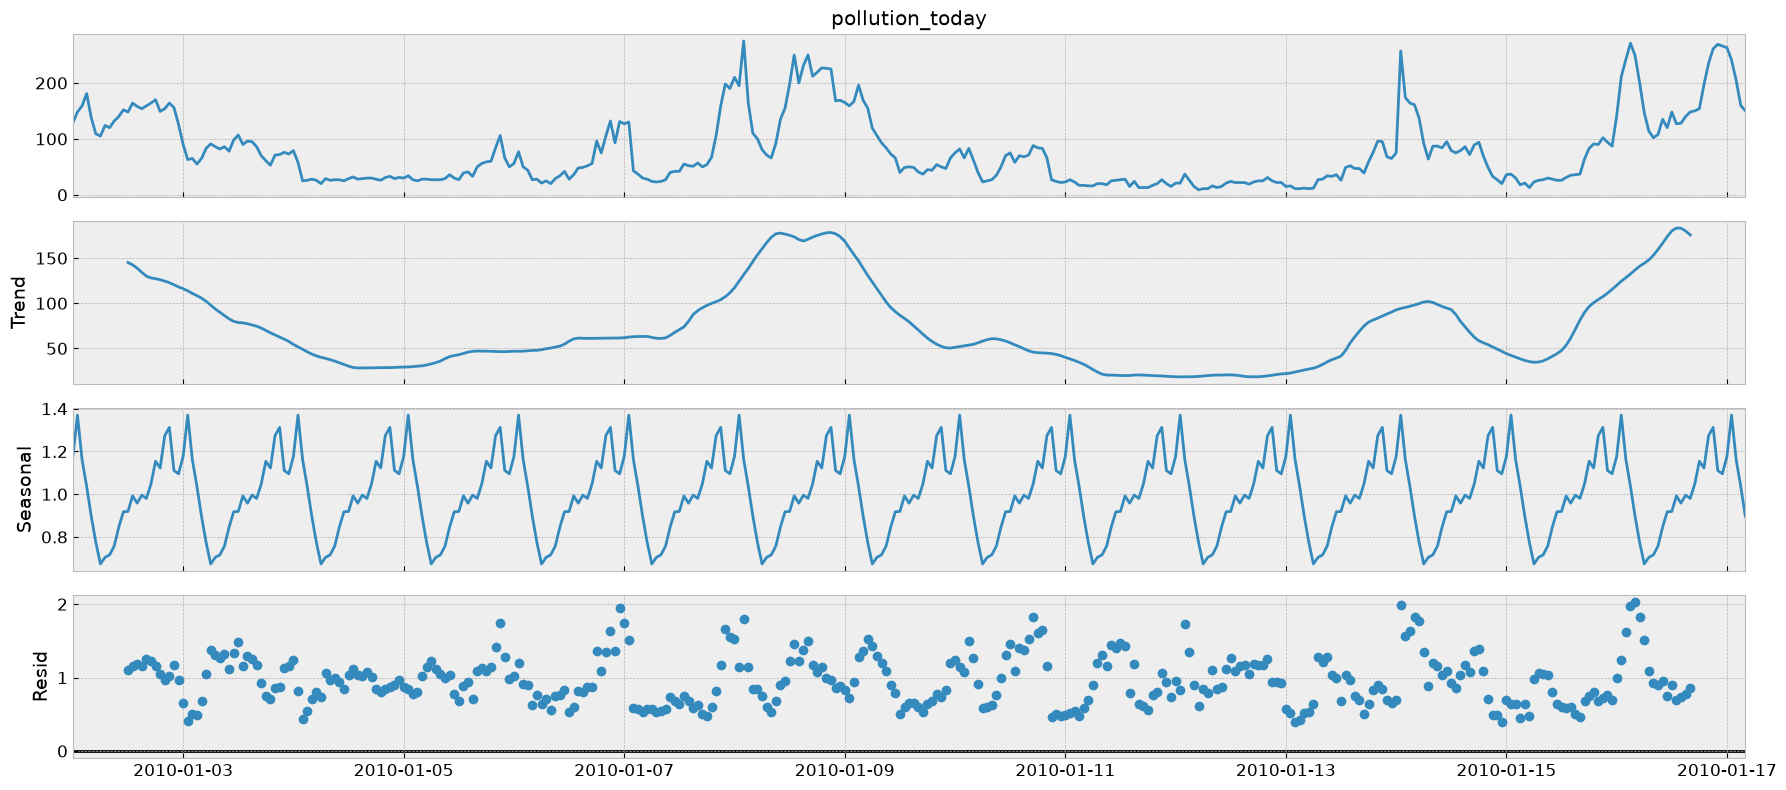

<Figure size 4000x1600 with 0 Axes>

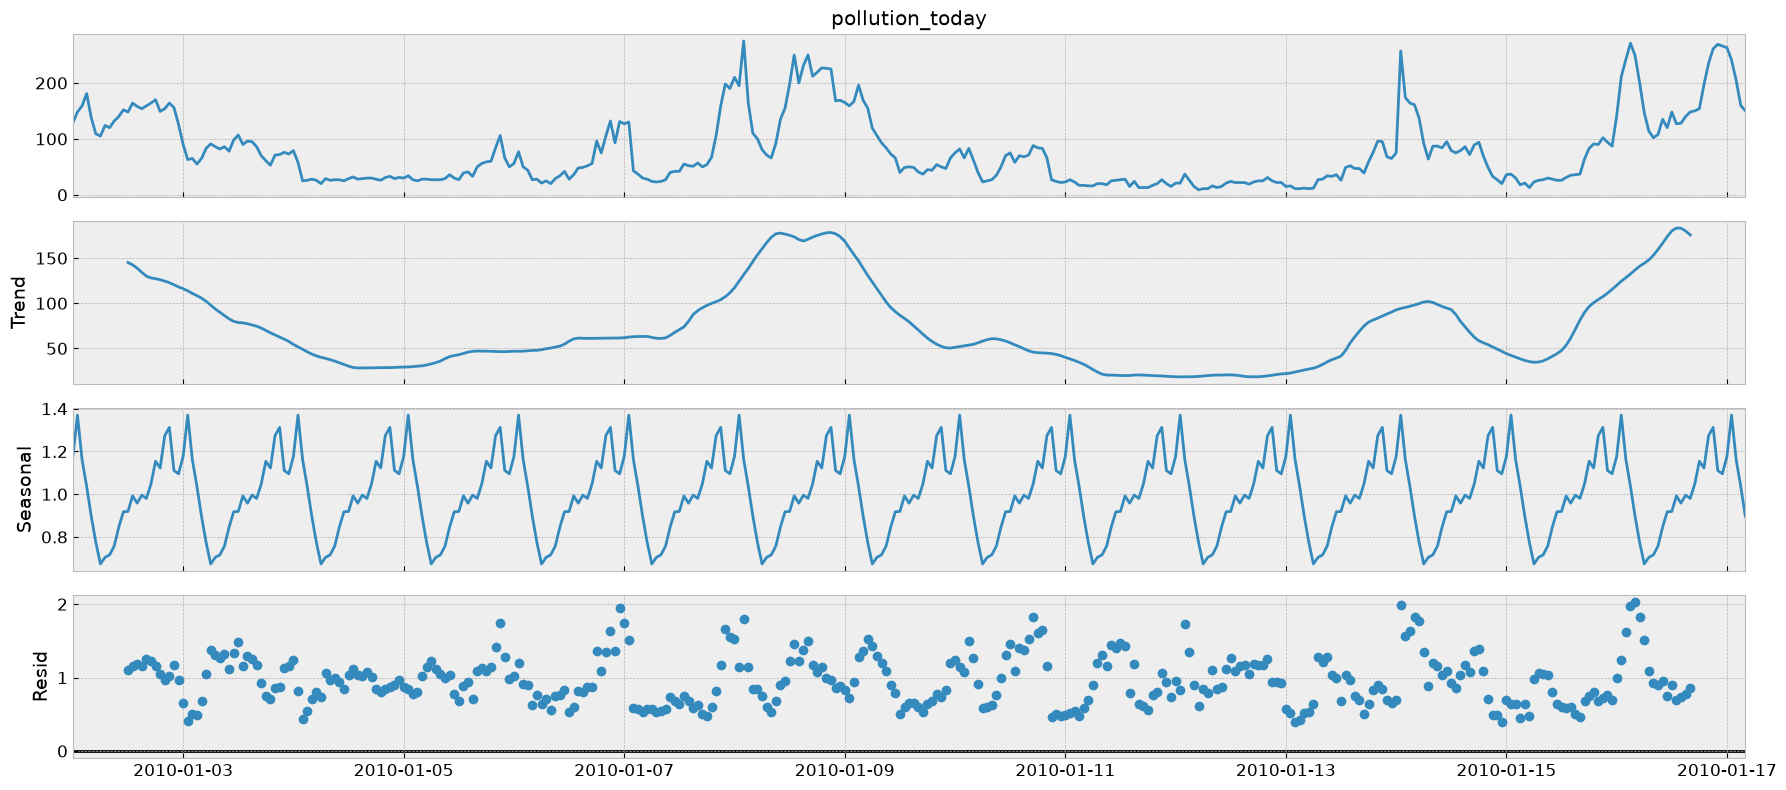

In [23]:
rcParams['figure.figsize']=18, 8
plt.figure(num=None, figsize=(50,20), dpi=80, facecolor='w',edgecolor='k')
series = air_pollution.pollution_today[:365]

result= seasonal_decompose(series, model='multiplicative')
result.plot()

In [24]:
air_pollution.pollution_today[-365:].min()

np.float64(0.0)

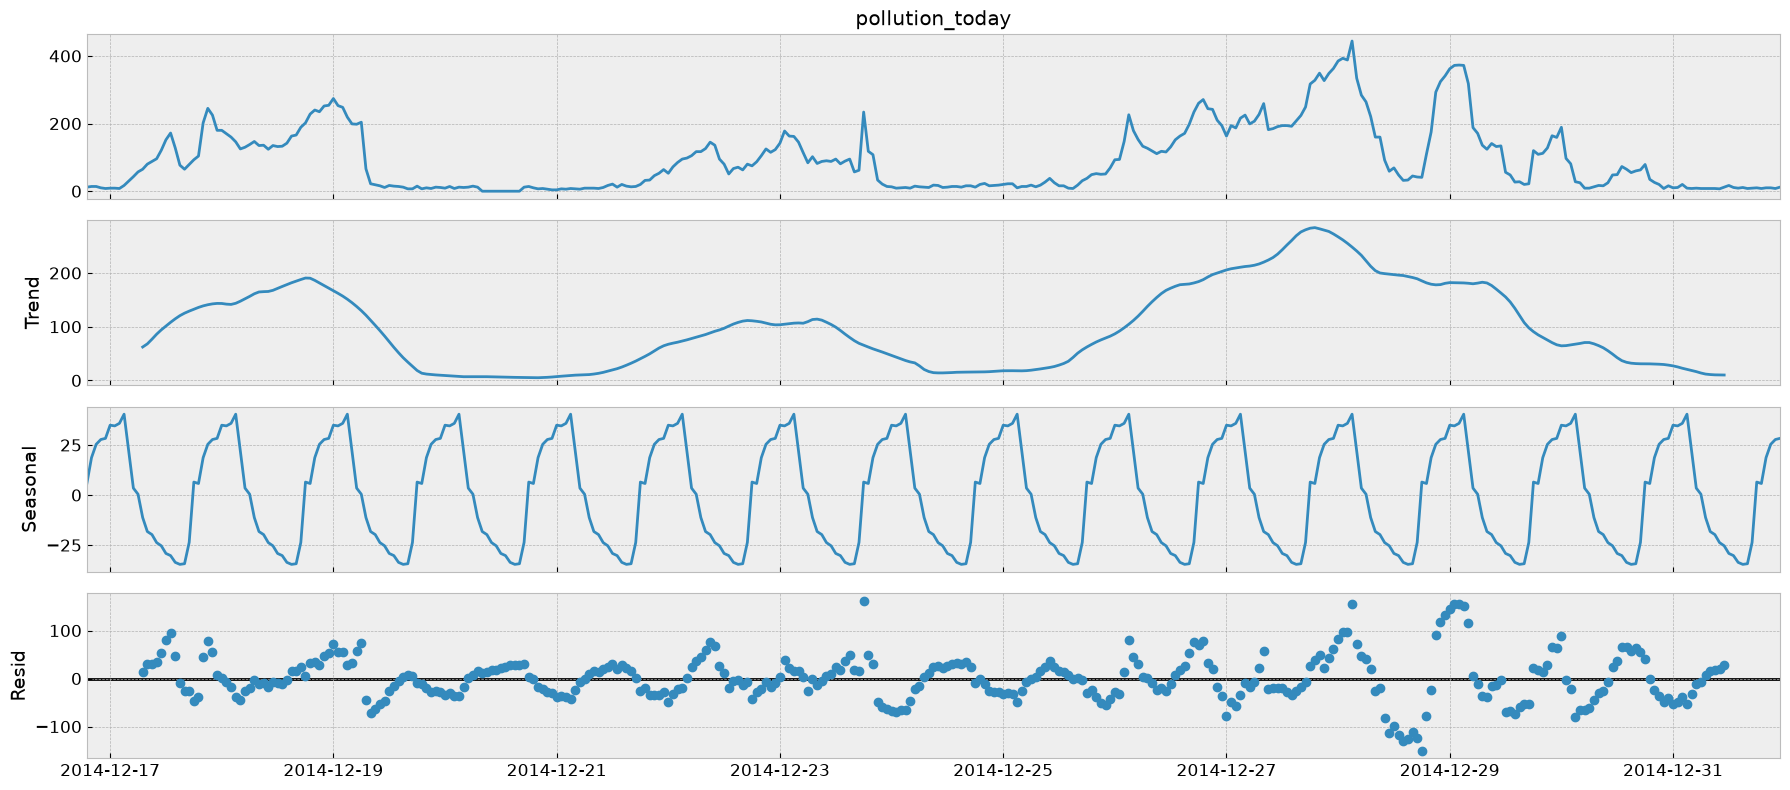

<Figure size 4000x1600 with 0 Axes>

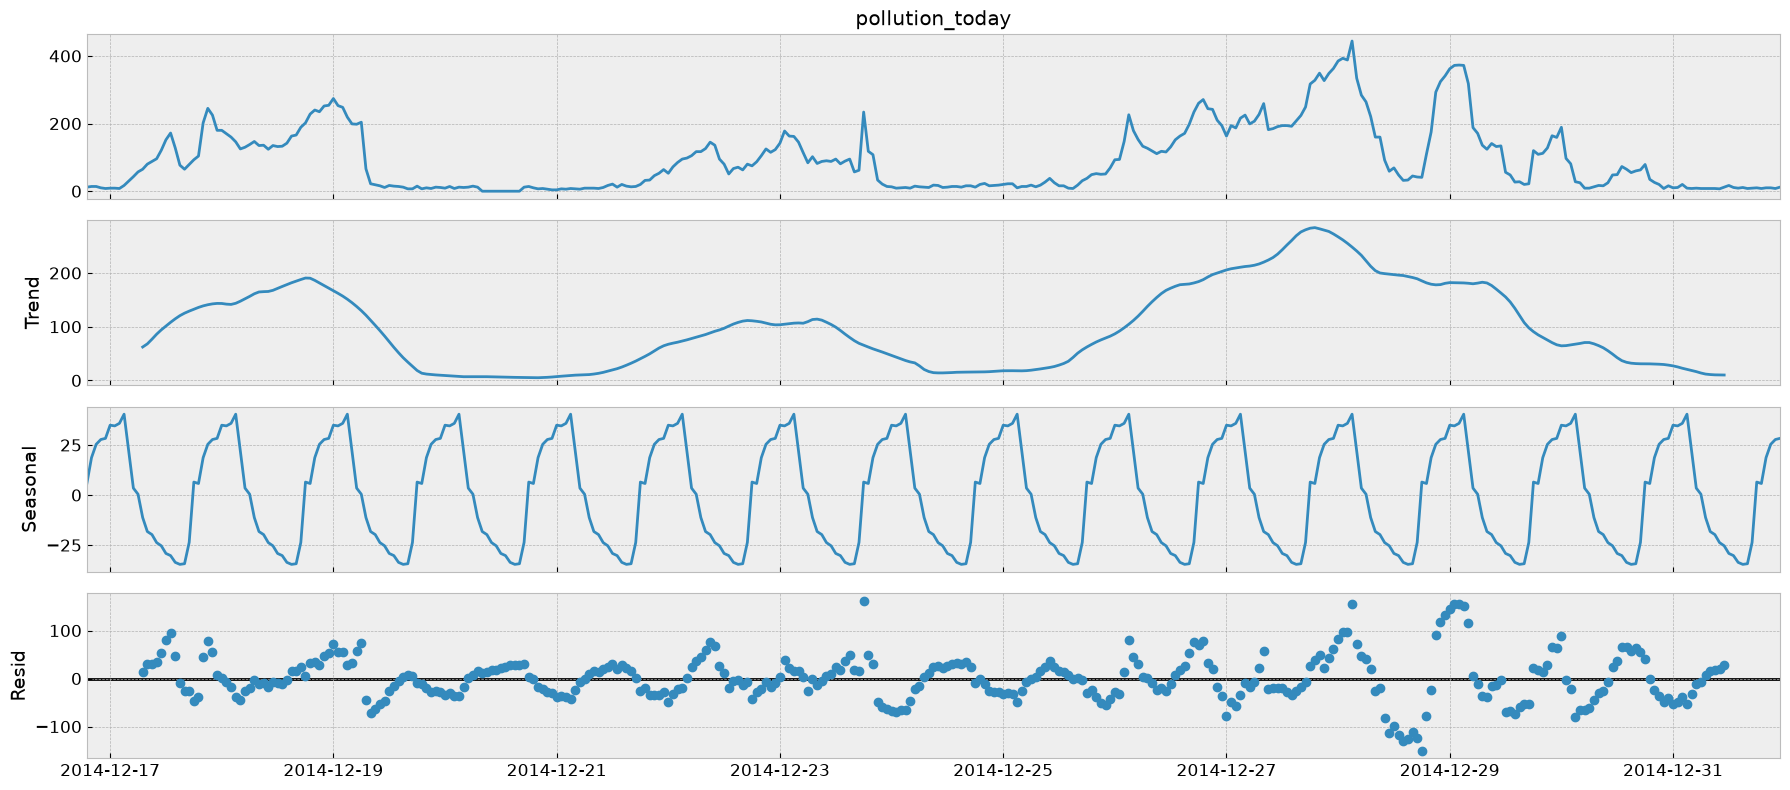

In [25]:
rcParams['figure.figsize']=18, 8
plt.figure(num=None, figsize=(50,20), dpi=80, facecolor='w',edgecolor='k')
series = air_pollution.pollution_today[-365:]

result= seasonal_decompose(series, model='aditive')
result.plot()

In [26]:
air_pollution

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution_yesterday
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0,NaN
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0,129.0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0,148.0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0,159.0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0,181.0
...,...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0,10.0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0,8.0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0,10.0
2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0,10.0


In [27]:
resample = air_pollution.pollution_today.resample('W')
resample.mean()

2010-01-03    112.395833
2010-01-10     74.452381
2010-01-17     86.708333
2010-01-24    108.452381
2010-01-31     49.815476
                 ...    
2014-12-07     37.535714
2014-12-14     79.214286
2014-12-21     67.059524
2014-12-28    120.648810
2015-01-04     71.708333
Freq: W-SUN, Name: pollution_today, Length: 262, dtype: float64

**Resampling**

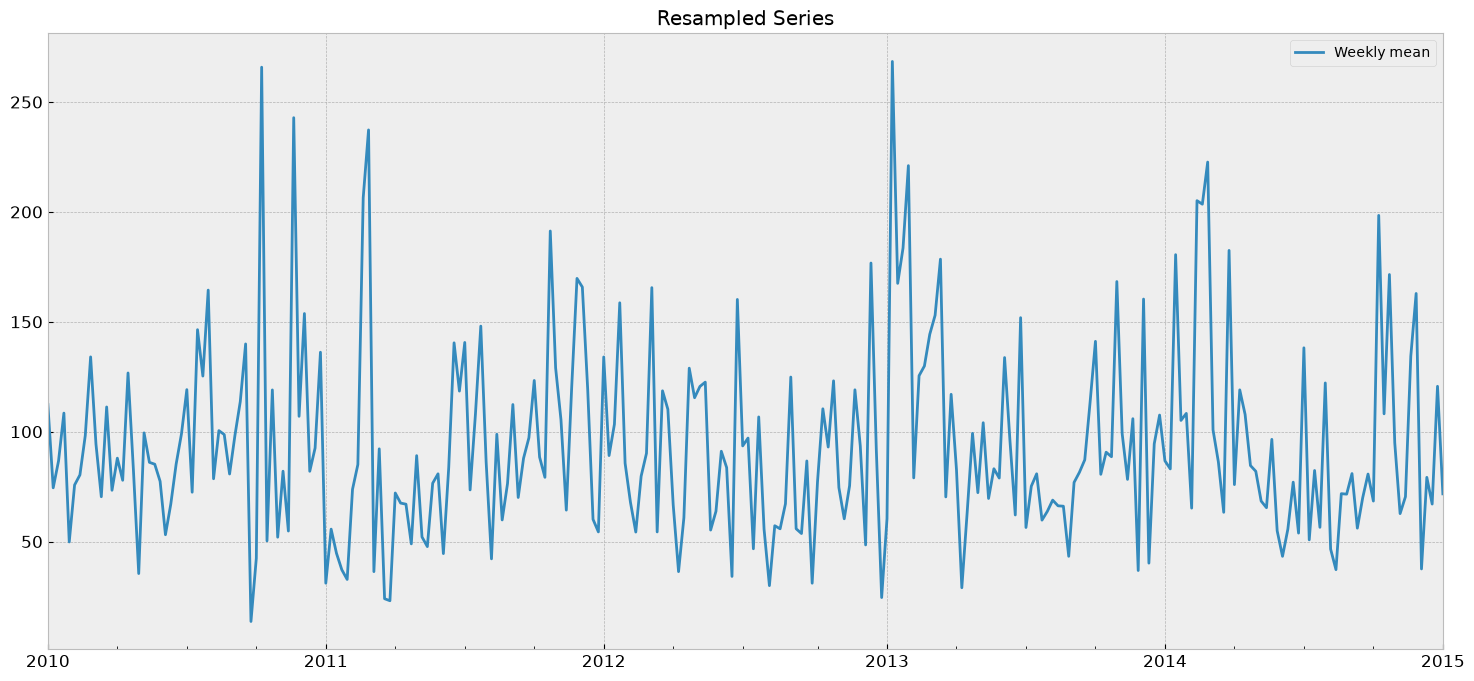

In [28]:
resample = air_pollution.pollution_today.resample('W')
weekly_mean = resample.mean()
weekly_mean.plot(label='Weekly mean')
plt.title("Resampled Series")
plt.legend()
plt.show()

# Noise in Automatic Time Series Decomposition

**Noise**

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

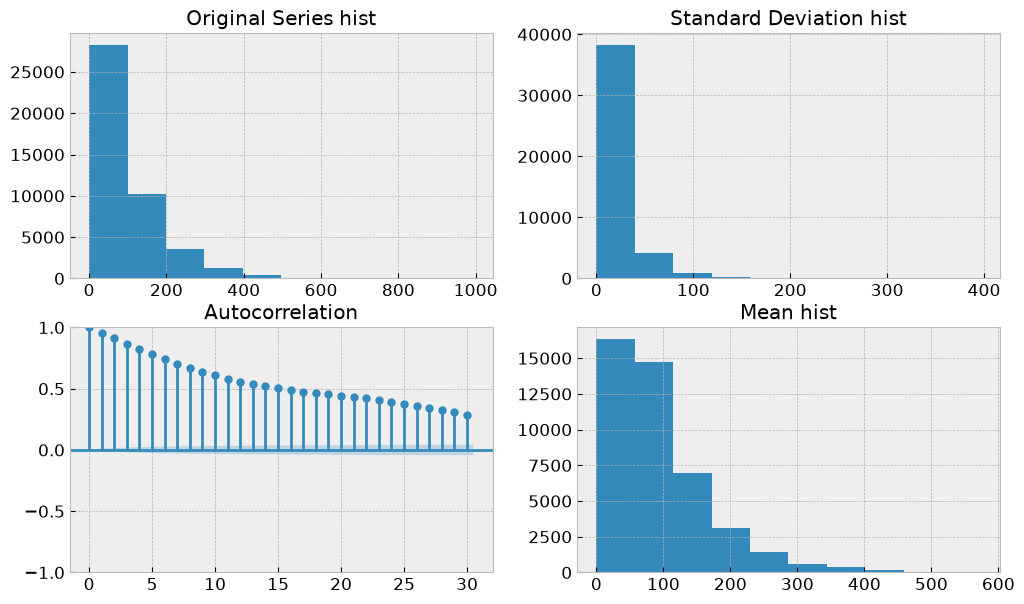

In [30]:
fig = plt.figure(figsize=(12,7))
layout=(2,2)

hist_ax=plt.subplot2grid(layout,(0,0))
ac_ax=plt.subplot2grid(layout,(1,0))
hist_std_ax=plt.subplot2grid(layout,(0,1))
mean_ax=plt.subplot2grid(layout,(1,1))

air_pollution.pollution_today.hist(ax=hist_ax)
hist_ax.set_title("Original Series hist")


plot_acf(air_pollution.pollution_today, lags=30, ax=ac_ax)
ac_ax.set_title("Autocorrelation")

mm = air_pollution.pollution_today.rolling(7).std()
mm.hist(ax=hist_std_ax)
hist_std_ax.set_title("Standard Deviation hist")

mm = air_pollution.pollution_today.rolling(30).mean()
mm.hist(ax=mean_ax)
mean_ax.set_title("Mean hist")

plt.show()

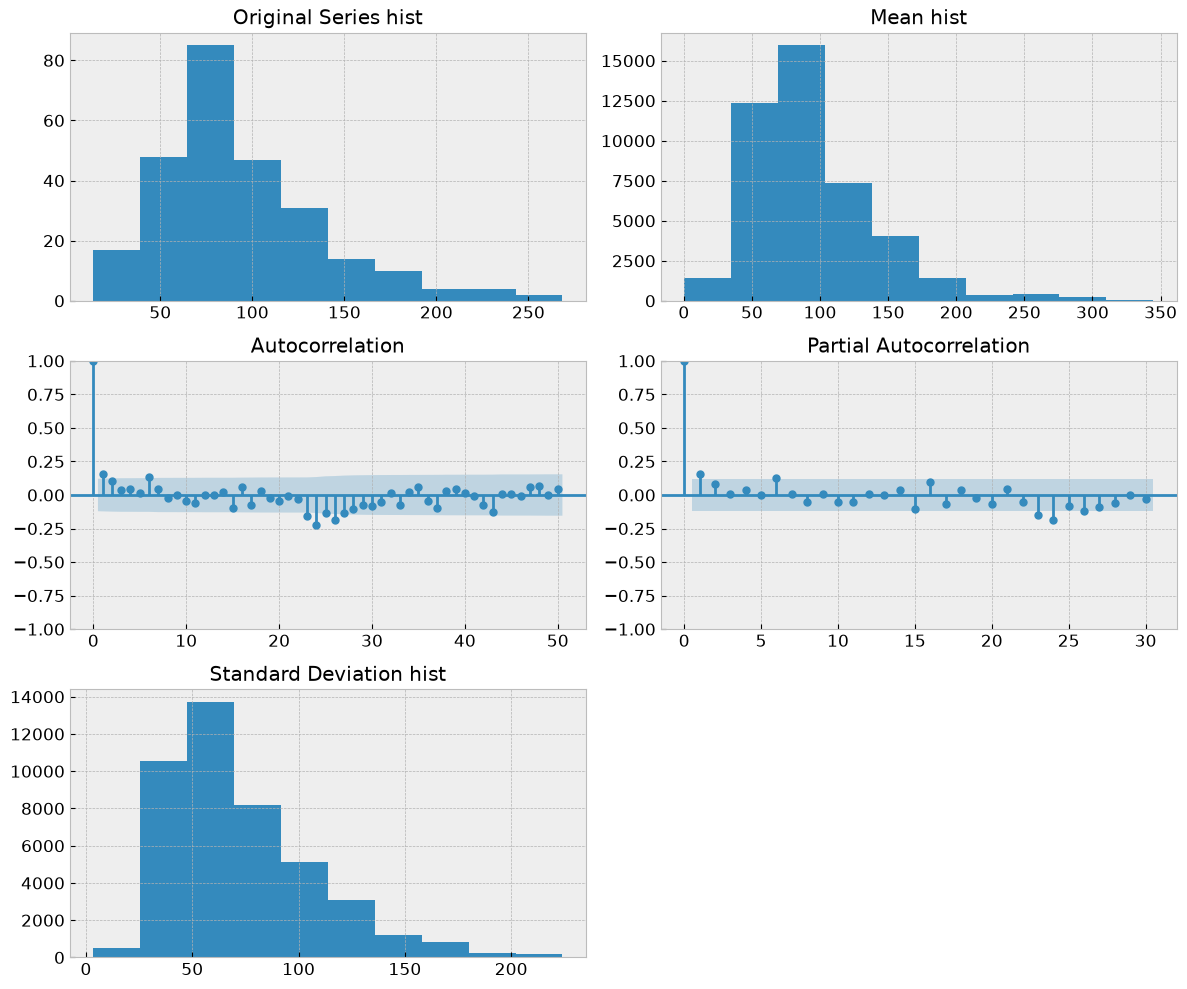

In [31]:
fig = plt.figure(figsize=(12,10))
layout=(3,2)

hist_ax=plt.subplot2grid(layout,(0,0))
ac_ax=plt.subplot2grid(layout,(1,0))
hist_std_ax=plt.subplot2grid(layout,(2,0))
mean_ax=plt.subplot2grid(layout,(0,1))
pac_ax=plt.subplot2grid(layout,(1,1))

weekly_mean.hist(ax=hist_ax)
hist_ax.set_title("Original Series hist")


plot_acf(weekly_mean, lags=50, ax=ac_ax)
ac_ax.set_title("Autocorrelation")

mm = air_pollution.pollution_today.rolling(24*7).std()
mm.hist(ax=hist_std_ax)
hist_std_ax.set_title("Standard Deviation hist")

mm = air_pollution.pollution_today.rolling(24*7).mean()
mm.hist(ax=mean_ax)
mean_ax.set_title("Mean hist")

plot_pacf(weekly_mean, lags=30, ax=pac_ax)
pac_ax.set_title("Partial Autocorrelation")

plt.tight_layout()

plt.show()

# Feature Engineering and Stationarity in Time Series



**extracting parts of a date**


In [32]:
air_pollution.reset_index(inplace=True)

In [33]:
air_pollution.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   index                43800 non-null  datetime64[ns]
 1   pollution_today      43800 non-null  float64       
 2   dew                  43800 non-null  int64         
 3   temp                 43800 non-null  float64       
 4   press                43800 non-null  float64       
 5   wnd_dir              43800 non-null  object        
 6   wnd_spd              43800 non-null  float64       
 7   snow                 43800 non-null  int64         
 8   rain                 43800 non-null  int64         
 9   pollution_yesterday  43799 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(3), object(1)
memory usage: 3.3+ MB


In [34]:
air_pollution

,index,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution_yesterday
0,2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0,NaN
1,2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0,129.0
2,2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0,148.0
3,2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0,159.0
4,2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0,181.0
...,...,...,...,...,...,...,...,...,...,...
43795,2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0,10.0
43796,2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0,8.0
43797,2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0,10.0
43798,2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0,10.0


In [35]:
air_pollution['day']= air_pollution['index'].dt.day
air_pollution['month']= air_pollution['index'].dt.month
air_pollution['year']= air_pollution['index'].dt.year
air_pollution.set_index('index', inplace= True)

air_pollution

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution_yesterday,day,month,year
index,,,,,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0,NaN,2,1,2010
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0,129.0,2,1,2010
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0,148.0,2,1,2010
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0,159.0,2,1,2010
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0,181.0,2,1,2010
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0,10.0,31,12,2014
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0,8.0,31,12,2014
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0,10.0,31,12,2014


**numerical transformations**


In [36]:
air_pollution['pollution_today']= np.round(air_pollution['pollution_today'], decimals=3)
air_pollution['dew']= np.round(air_pollution['dew'], decimals=3)
air_pollution['temp']= np.round(air_pollution['temp'], decimals=3)
air_pollution['pollution_yesterday']= np.round(air_pollution['pollution_yesterday'], decimals=3)

In [37]:
air_pollution

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution_yesterday,day,month,year
index,,,,,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0,NaN,2,1,2010
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0,129.0,2,1,2010
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0,148.0,2,1,2010
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0,159.0,2,1,2010
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0,181.0,2,1,2010
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0,10.0,31,12,2014
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0,8.0,31,12,2014
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0,10.0,31,12,2014


#  Stationarity in Time Series  

#  Augmented Dickey-Fuller test for Stationarity in Time Series  


**Augmented Dickey-Fuller test**


In [38]:
from statsmodels.tsa.stattools import adfuller

In [39]:
X = air_pollution.pollution_today.values

In [40]:
result = adfuller(X)

In [41]:
print('ADF Statistics: %f'% result[0])
print('p value %f'% result[1])
print('critical values:')
for key, value in result[4].items():
    print('\t%s: %.3f'%(key, value))

ADF Statistics: -21.004109
p value 0.000000
critical values:
	1%: -3.430
	5%: -2.862
	10%: -2.567


# How to Make any time series a Stationary Time Series

In [42]:
passengers = pd.read_csv("airline-passengers.csv")

In [43]:
passengers.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [44]:
result = adfuller(passengers['Passengers'])

## p value mayor que 0.05 significa que la serie NO es estacionaria

## p value menor que 0.05 significa que la serie ES estacionaria

In [45]:
print('ADF Statistics: %f'% result[0])
print('p value %f'% result[1])
print('critical values:')
for key, value in result[4].items():
    print('\t%s: %.3f'%(key, value))

ADF Statistics: 0.815369
p value 0.991880
critical values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


In [46]:
df_log = np.sqrt(passengers['Passengers'])
df_diff = df_log.diff().dropna()

In [47]:
result = adfuller(df_diff)
print('ADF Statistics: %f'% result[0])
print('p value %f'% result[1])
print('critical values:')
for key, value in result[4].items():
    print('\t%s: %.3f'%(key, value))

ADF Statistics: -3.186422
p value 0.020784
critical values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


In [48]:
help (adfuller)

Help on function adfuller in module statsmodels.tsa.stattools:

adfuller(
    x,
    maxlag: int | None = None,
    regression='c',
    autolag='AIC',
    store=False,
    regresults=False
)
    Augmented Dickey-Fuller unit root test.

    The Augmented Dickey-Fuller test can be used to test for a unit root in a
    univariate process in the presence of serial correlation.

    Parameters
    ----------
    x : array_like, 1d
        The data series to test.
    maxlag : {None, int}
        Maximum lag which is included in test, default value of
        12*(nobs/100)^{1/4} is used when ``None``.
    regression : {"c","ct","ctt","n"}
        Constant and trend order to include in regression.

        * "c" : constant only (default).
        * "ct" : constant and trend.
        * "ctt" : constant, and linear and quadratic trend.
        * "n" : no constant, no trend.

    autolag : {"AIC", "BIC", "t-stat", None}
        Method to use when automatically determining the lag length among th

In [49]:
air_pollution

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution_yesterday,day,month,year
index,,,,,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0,NaN,2,1,2010
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0,129.0,2,1,2010
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0,148.0,2,1,2010
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0,159.0,2,1,2010
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0,181.0,2,1,2010
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0,10.0,31,12,2014
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0,8.0,31,12,2014
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0,10.0,31,12,2014


In [50]:
 air_pollution['hour']= air_pollution.index.hour

In [51]:
air_pollution

,pollution_today,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution_yesterday,day,month,year,hour
index,,,,,,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0,NaN,2,1,2010,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0,129.0,2,1,2010,1
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0,148.0,2,1,2010,2
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0,159.0,2,1,2010,3
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0,181.0,2,1,2010,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0,10.0,31,12,2014,19
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0,8.0,31,12,2014,20
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0,10.0,31,12,2014,21


In [52]:
air_pollution.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43800 entries, 2010-01-02 00:00:00 to 2014-12-31 23:00:00
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pollution_today      43800 non-null  float64
 1   dew                  43800 non-null  int64  
 2   temp                 43800 non-null  float64
 3   press                43800 non-null  float64
 4   wnd_dir              43800 non-null  object 
 5   wnd_spd              43800 non-null  float64
 6   snow                 43800 non-null  int64  
 7   rain                 43800 non-null  int64  
 8   pollution_yesterday  43799 non-null  float64
 9   day                  43800 non-null  int32  
 10  month                43800 non-null  int32  
 11  year                 43800 non-null  int32  
 12  hour                 43800 non-null  int32  
dtypes: float64(5), int32(4), int64(3), object(1)
memory usage: 4.0+ MB
